# Applications of OSMnx: Routing and Network Analysis

In this notebook, you'll 
In this notebook, you'll learn how to:

- Perform routing (walking and driving) on UIUC and Champaign–Urbana networks
- Measure travel time and compare alternative routes 
- Compute isochrones (accessibility areas) from a chosen location 
- Find the nearest POI and compute a route to it 
- Compare multiple cities using street network metrics


## 1. Setup: Import Libraries and Download Networks

In [3]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union

# Enable OSMnx caching so repeated downloads are faster
ox.settings.use_cache = True
# Print progress and logging information to the console
ox.settings.log_console = True

# Check which OSMnx version is installed (important for API changes)
print('OSMnx version:', ox.__version__)

OSMnx version: 1.2.2


### Download Street Networks

We will work with:

- A **driving** network for Champaign–Urbana  
- A **walking** network focused on the UIUC campus

In [4]:
# Define place names for the driving and walking networks
places = ["Champaign, Illinois, USA", "Urbana, Illinois, USA"]
campus_place = 'University of Illinois Urbana-Champaign'

# Driving network (for cars)
G_drive = ox.graph_from_place(places, network_type='drive')

# Walking network (for pedestrians on campus)
G_walk_uiuc = ox.graph_from_place(campus_place, network_type='walk')

# Display a summary (NetworkX MultiDiGraph objects)
G_drive, G_walk_uiuc

(<networkx.classes.multidigraph.MultiDiGraph at 0x7f1872f86c40>,
 <networkx.classes.multidigraph.MultiDiGraph at 0x7f18725f68e0>)

## 2. Routing Basics: UIUC Walking Network

We will find routes between familiar UIUC landmarks, for example:

- **Illini Union**  
- **Main Quad**  
- **Siebel Center for Computer Science**

We will use OSMnx's geocoding and routing functions.

In [5]:
# Define location strings for three UIUC landmarks
loc_illini_union = 'Illini Union, Urbana, Illinois, USA'
loc_main_quad = 'Main Quad, Urbana, Illinois, USA'
loc_siebel = 'Siebel Center for Computer Science, Urbana, Illinois, USA'

# Geocode each location string into (latitude, longitude) coordinates
pt_illini_union = ox.geocode(loc_illini_union)
pt_main_quad = ox.geocode(loc_main_quad)
pt_siebel = ox.geocode(loc_siebel)

# Show the resulting coordinate tuples
pt_illini_union, pt_main_quad, pt_siebel

((40.1104071, -88.2281649),
 (40.1076291, -88.2272075),
 (40.1140429, -88.2244345))

**Find Nearest Nodes in the Walking Network**

In [6]:
# Unpack latitude and longitude for each location
lat_iu, lon_iu = pt_illini_union
lat_quad, lon_quad = pt_main_quad
lat_siebel, lon_siebel = pt_siebel

# Find the nearest graph node to each point within the UIUC walking network
# Note: OSMnx expects X = longitude, Y = latitude
node_iu = ox.distance.nearest_nodes(G_walk_uiuc, X=lon_iu, Y=lat_iu)
node_quad = ox.distance.nearest_nodes(G_walk_uiuc, X=lon_quad, Y=lat_quad)
node_siebel = ox.distance.nearest_nodes(G_walk_uiuc, X=lon_siebel, Y=lat_siebel)

# Display node IDs for the three locations
node_iu, node_quad, node_siebel

(6056225667, 1997964694, 6615510919)

**Shortest Path (by Distance) from Illini Union to Siebel Center**

In [7]:
# Compute the shortest path between Illini Union and Siebel Center
# Here, weight='length' means we minimize total path distance (meters)
route_iu_siebel = ox.shortest_path(G_walk_uiuc, node_iu, node_siebel, weight='length')

# Show the first 10 nodes along the path
route_iu_siebel[:10]

[6056225667,
 6056225665,
 5434361503,
 6056225651,
 12576964017,
 6056225650,
 1509407268,
 12159081164,
 12159081155,
 2031459999]

**Visualize the Route**

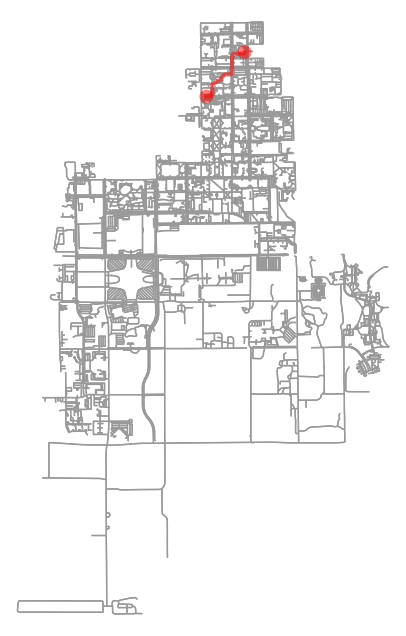

In [8]:
# Plot the walking network and overlay the computed route
fig, ax = ox.plot_graph_route(
    G_walk_uiuc,
    route_iu_siebel,
    route_linewidth=3,
    node_size=0,
    bgcolor='white'
)

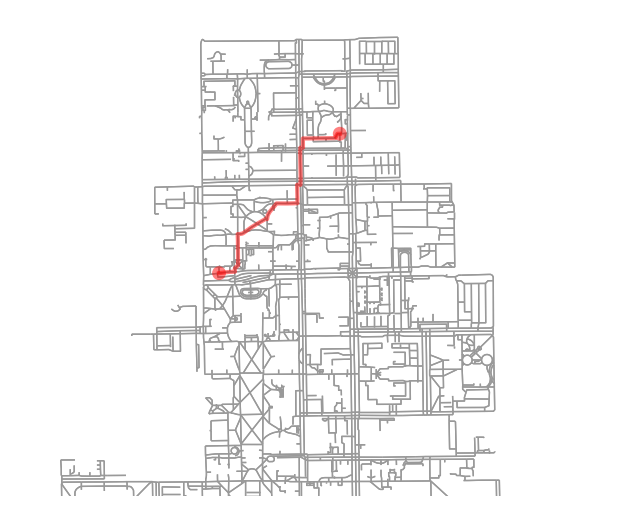

In [9]:
# Optionally zoom in to a bounding box around the route (north, south, east, west)
bbox = (40.1170, 40.1050, -88.2150, -88.2350) # north, south, east, west

# Re-plot the same route, but restricted to the specified bounding box
fig, ax = ox.plot_graph_route(
    G_walk_uiuc,
    route_iu_siebel,
    route_linewidth=3,
    node_size=0,
    bgcolor='white',
    bbox = bbox
)

## 3. Driving Routes: Shortest Time vs. Shortest Distance

We will compare:

- Shortest distance
- Shortest travel time (after adding speed data)

Example:

- Origin: Illini Union  
- Destination: Market Place Shopping Center (north Champaign)

#### Prepare nodes

In [10]:
# Define origin and destination location strings
origin_str = 'Illini Union, Urbana, Illinois, USA'
dest_str = 'Market Place Shopping Center, Champaign, Illinois, USA'

# Geocode origin and destination into coordinates
origin_pt = ox.geocode(origin_str)
dest_pt = ox.geocode(dest_str)

# Unpack latitude and longitude
lat_o, lon_o = origin_pt
lat_d, lon_d = dest_pt

# Find nearest nodes in the driving network to origin and destination
origin_node = ox.distance.nearest_nodes(G_drive, X=lon_o, Y=lat_o)
dest_node = ox.distance.nearest_nodes(G_drive, X=lon_d, Y=lat_d)

# Show node IDs for origin and destination in G_drive
origin_node, dest_node

(38065246, 10315407942)

#### Add Speeds and Travel Times

In [11]:
# Add edge speeds to the driving network
# OSMnx estimates speed_kph where it is missing, based on highway type
G_drive = ox.add_edge_speeds(G_drive)

# Add travel_time (seconds) to each edge, based on length and speed_kph
G_drive = ox.add_edge_travel_times(G_drive)

# Inspect attributes of one edge to see length, speed, and travel_time
list(G_drive.edges(data=True))[0]

(37945125,
 38011734,
 {'osmid': 143324749,
  'lanes': '2',
  'name': 'South Race Street',
  'highway': 'tertiary',
  'oneway': False,
  'reversed': False,
  'length': 146.974,
  'speed_kph': 47.8,
  'travel_time': 11.1})

#### Compare Shortest Path by Distance vs by Travel Time

In [12]:
# Compute shortest path by physical distance (meters)
route_distance = ox.shortest_path(G_drive, origin_node, dest_node, weight='length')

# Compute shortest path by travel time (seconds)
route_time = ox.shortest_path(G_drive, origin_node, dest_node, weight='travel_time')

# Compare the number of edges (steps) in each route
len(route_distance), len(route_time)

(46, 41)

#### Plot Both Routes for Comparison

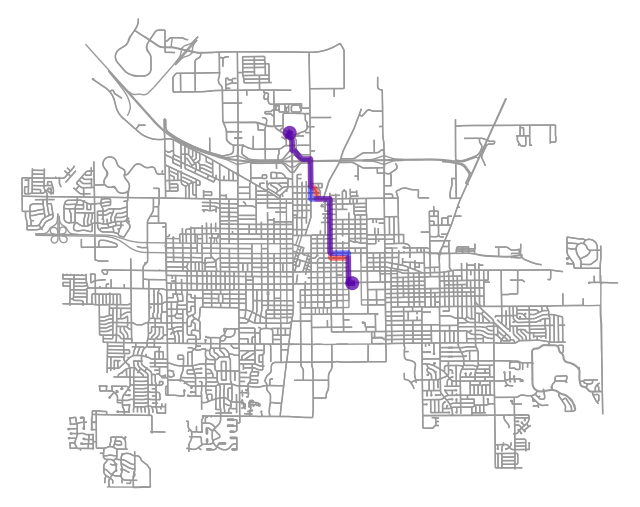

In [13]:
# Plot both routes on the same map to visually compare them
fig, ax = ox.plot_graph_routes(
    G_drive,
    routes=[route_distance, route_time], # first route: distance, second: time
    route_colors=['red', 'blue'],       # color-code the routes
    route_linewidth=2,
    node_size=0,
    bgcolor='white'
)

## 4. Accessibility Analysis: Isochrones from Illini Union

An **isochrone** is a region that is reachable within a certain amount of travel time from a given origin.

We will:

- Use the driving network  
- Choose Illini Union as the center  
- Compute areas reachable within 3 and 5 minutes of driving

In [14]:
# Use the origin_node (Illini Union) as the isochrone center
center_node = origin_node # Illini Union

# To ensure accurate distance calculations, 
# we must project the street network into a planar CRS (meters) before buffering.
G_drive_proj = ox.project_graph(G_drive)
nodes_drive_proj, edges_drive_proj = ox.graph_to_gdfs(G_drive_proj)

# (Optional) Inspect the first few rows if needed
# display(nodes_drive_proj.head(), edges_drive_proj.head())

#### Compute Isochrone Polygons

In [15]:
def make_iso_polys(G_proj, center_node, trip_times):
    # Compute travel-time from center_node to all reachable nodes
    travel_time = nx.single_source_dijkstra_path_length(
        G_proj, center_node, weight='travel_time'
    )

    iso_polys = []
    # Loop over travel-time thresholds in ascending order
    for tt in sorted(trip_times):
        # Select nodes whose travel_time is within the threshold tt
        subnodes = [n for n, t in travel_time.items() if t <= tt]
        # Extract the subgraph induced by subnodes
        subgraph = G_proj.subgraph(subnodes)
        # Convert subgraph to GeoDataFrames (we only need edges)
        _, subedges = ox.graph_to_gdfs(subgraph)

        # If no edges, skip this threshold
        if len(subedges) == 0:
            continue

        # Buffer the selected edges to create a polygon representing the isochrone
        # A buffer of ~50–80 m is typical for street centerlines
        merged = subedges.buffer(80).unary_union
        
        # Store (threshold, polygon)
        iso_polys.append((tt, merged))

    return iso_polys

# Define travel-time thresholds: 5 and 10 minutes (in seconds)
trip_times = [5*60, 10*60]  
# Generate isochrone polygons
iso_polys = make_iso_polys(G_drive_proj, center_node, trip_times)

#### Plot Isochrones Around Illini Union

/tmp/ipykernel_247/3944012539.py:15: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


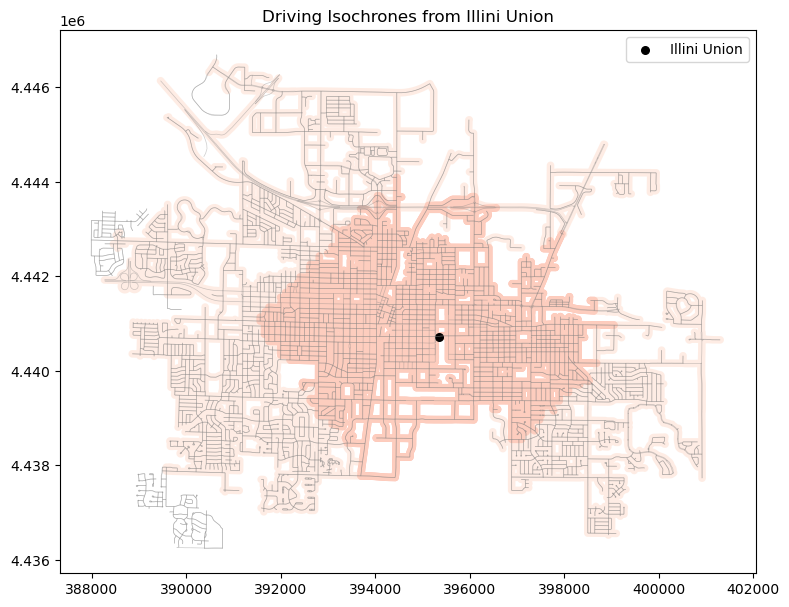

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))
# Plot the projected street edges as a base layer
edges_drive_proj.plot(ax=ax, linewidth=0.5, alpha=0.4, color='gray')

colors = ['#fb6a4a', '#fee5d9']
# Plot each isochrone polygon
for (tt, poly), color in zip(iso_polys, colors):
    gpd.GeoSeries([poly]).plot(ax=ax, facecolor=color, edgecolor='none', 
                               alpha=0.7, label=f'{tt/60:.0f} min')  
    
# Plot the center node (Illini Union) as a point
node_geom = nodes_drive_proj.loc[center_node].geometry
gpd.GeoSeries([node_geom]).plot(ax=ax, color='black', markersize=30, label='Illini Union')

ax.legend()
ax.set_title('Driving Isochrones from Illini Union')
plt.tight_layout()

## 5. Service Area Example: Nearest Grocery Store from a Dorm

This example demonstrates how to perform a simple service area and routing analysis using OSMnx.   

Starting from a dormitory location (Illini Union: `origin_pt`), we identify the nearest grocery store and compute the shortest driving route to reach it.

In [21]:
# Extract grocery stores
groceries = ox.geometries_from_place(
    places, tags={'shop': 'supermarket'}
)


# Compute route from the origin (Illini Union) to the nearest supermarket
# Convert graph to GeoDataFrames to get node geometries
nodes_drive, _ = ox.graph_to_gdfs(G_drive)

# Unpack origin latitude and longitude
lat, lon = origin_pt
# Get the nearest network node to the origin point
origin_node = ox.distance.nearest_nodes(G_drive, X=lon, Y=lat)
    
# Find nearest POI
# Reproject POIs to match the graph's CRS
groceries = groceries.to_crs(G_drive.graph['crs'])
# Extract POI geometries (points or centroids of polygons)
poi_points = groceries.geometry
# Find the POI geometry that is closest to the origin node's geometry
# by minimizing Euclidean distance in the graph's CRS
nearest = min(poi_points, key=lambda p: p.distance(nodes_drive.loc[origin_node].geometry))
    
# Get the nearest network node to the POI
dest_node = ox.distance.nearest_nodes(G_drive, X=nearest.x, Y=nearest.y)
# Compute shortest-time route from origin node to destination node
route = ox.shortest_path(G_drive, origin_node, dest_node, weight='travel_time')


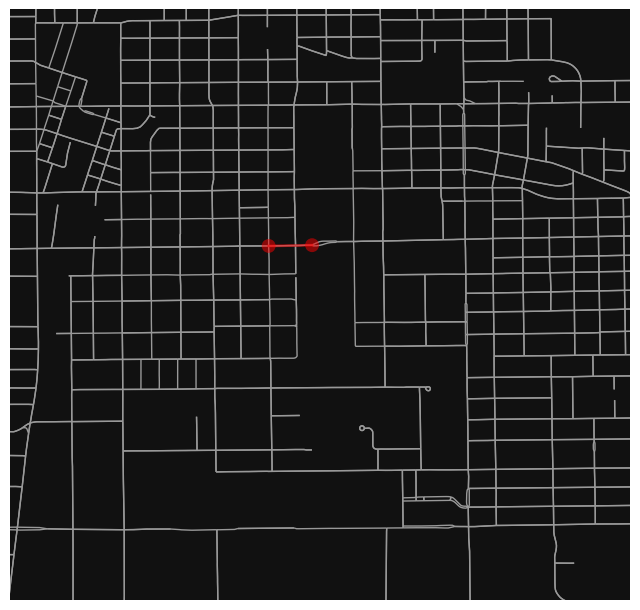

In [22]:
# Define a bounding box that roughly covers the campus area
bbox = (40.1205, 40.0950, -88.2100, -88.2450) # north, south, east, west

# Plot the driving network and the route to the nearest grocery store
fig, ax = ox.plot_graph_route(G_drive, route, node_size=0, route_linewidth=2, bbox=bbox)

## 6. Street Network Statistics: Champaign–Urbana vs Another City

We can compute basic network statistics to compare different urban areas, such as:

- Total street length  
- Intersection density  
- Block size and segment length

In this example, we compare Champaign–Urbana with Springfield, Illinois (a smaller city) and Manhattan, New York (a dense urban core).

You are encouraged to explore any additional cities of interest by modifying the place names in the code.  
Note that downloading and analyzing multiple city networks may take **noticeably longer**, especially for larger cities.

In [23]:
# Download driving networks for Springfield, IL and Manhattan, NY
G_springfield = ox.graph_from_place('Springfield, Illinois, USA', network_type='drive')
G_manhattan = ox.graph_from_place('Manhattan, New York City, USA', network_type='drive')
# G_chicago = ox.graph_from_place('Chicago, Illinois, USA', network_type='drive')

In [24]:
# Compute basic stats
stats = {}
for name, G in [('CU', G_drive), ('Springfield', G_springfield), ('Manhattan', G_manhattan)]:
    stats[name] = ox.basic_stats(G)
stats

{'CU': {'n': 3542,
  'm': 9963,
  'k_avg': 5.625635234330886,
  'edge_length_total': 1384937.4280000005,
  'edge_length_avg': 139.0080726688749,
  'streets_per_node_avg': 3.0886504799548278,
  'streets_per_node_counts': {0: 0, 1: 366, 2: 31, 3: 2085, 4: 1043, 5: 17},
  'streets_per_node_proportions': {0: 0.0,
   1: 0.10333145115753811,
   2: 0.008752117447769622,
   3: 0.5886504799548278,
   4: 0.29446640316205536,
   5: 0.004799548277809147},
  'intersection_count': 3176,
  'street_length_total': 752382.5009999962,
  'street_segment_count': 5391,
  'street_length_avg': 139.56269727323246,
  'circuity_avg': 1.0523582008584118,
  'self_loop_proportion': 0.01854943424225561},
 'Springfield': {'n': 5080,
  'm': 12879,
  'k_avg': 5.070472440944882,
  'edge_length_total': 1829444.0469999972,
  'edge_length_avg': 142.0486099076013,
  'streets_per_node_avg': 2.906496062992126,
  'streets_per_node_counts': {0: 0,
   1: 881,
   2: 52,
   3: 2871,
   4: 1223,
   5: 43,
   6: 10},
  'streets_per_

### Interpretation of Each Metric
| **Metric Name**                  | **Interpretation**                                                                                           |
| -------------------------------- | ------------------------------------------------------------------------------------------------------------ |
| **n**                            | Number of nodes in the network (intersections + dead ends).                                                  |
| **m**                            | Number of edges (street segments, directed).                                                                 |
| **k_avg**                        | Average node degree; how many edges connect to each node → higher means more connected intersections.        |
| **edge_length_total**            | Total length (meters) of all directed edges.                                                                 |
| **edge_length_avg**              | Average length of directed street segments; reflects block size.                                             |
| **streets_per_node_avg**         | Average number of *unique streets* meeting at each node (e.g., 3 = T-intersection, 4 = 4-way intersection).  |
| **streets_per_node_counts**      | How many nodes have 1, 2, 3, 4, 5+ streets meeting (raw counts). Useful for understanding street morphology. |
| **streets_per_node_proportions** | Same as above, but as proportions of total nodes.                                                            |
| **intersection_count**           | Number of true intersections (nodes where ≥3 streets meet).                                                  |
| **street_length_total**          | Total length of *undirected* street centerlines (each street counted once).                                  |
| **street_segment_count**         | Number of unique (undirected) street segments.                                                               |
| **street_length_avg**            | Average length of undirected street segments; a measure of block size.                                       |
| **circuity_avg**                 | Ratio of actual street distance to straight-line distance → higher = more winding network.                   |
| **self_loop_proportion**         | Fraction of edges that start and end at same node (cul-de-sacs, roundabouts, data quirks).                   |


## 7. Conclusion

In this notebook, you have:

- Loaded **driving** and **walking** street networks for Champaign–Urbana and the UIUC campus using OSMnx.
- Performed **walking routes** between UIUC landmarks by geocoding locations, snapping them to the nearest network nodes, and computing shortest paths by distance.
- Computed and visualized **driving routes** between Illini Union and Market Place Shopping Center, comparing paths that minimize physical distance versus travel time.
- Derived and mapped **isochrones** (5- and 10-minute driving catchments) from Illini Union to visualize short-range accessibility.
- Implemented a **service area analysis** by locating the nearest supermarket to a given origin and routing to it.
- Calculated and interpreted **street network statistics** for ChampaignSpringfiled, Chicago, and Manhattan to compare connectivity, block structure, and overall network morphology.

These examples demonstrate how OSMnx enables routing, accessibility assessments, and comparative urban form analysis using OpenStreetMap data.
